# INF8111 - Fouille de données
## Automne 2026 - TP1 - Préparation des données de séries temporelles-Consommation électrique
### Membres de l'équipe.
    - Marfouk, Ayoub - 2295178 - 1
    - Oumerhouch, Youssra - Matricule - 2
    - Sejjari, Souhayl - 2185896 - 3


## Instructions de remise

Vous devez remettre dans la boîte de remise sur moodle ce fichier nommé TP1\_NomDuMembre1\_NomDuMembre2\_NomDuMembre3.ipynb

**N.B**: Assurez-vous que tous les résultats soient lisibles lorsque le notebook est ouvert.

Ce notebook doit être remis avant le **26 septembre 2026 à 23h59***. À l'ouverture du Notebook, toutes les réponses doivent être visibles. Tout travail en retard sera pénalisé d’une valeur de 10\% par jour ouvrable de retard.

## Barème

    Partie 1: 25 points
    
    Partie 2: 30 points
    
    Partie 3: 45 points
    
    Pour un total de 100 points.

## Séries temporelles

Les séries temporelles sont de plus en plus utilisées dans plusieurs domaines tels que la finance, la météorologie, la santé et la gestion de l'énergie pour modéliser, analyser et prévoir des phénomènes évolutifs. Une série temporelle correspond à une suite d’observations ordonnées dans le temps, collectées à intervalles réguliers ou irréguliers (par exemple : prix journaliers d’une action, température horaire, consommation électrique, etc.).
Ces données présentent une structure particulière caractérisée par la dépendance entre les observations successives. À partir de ces données temporelles, il devient possible d’identifier des tendances à long terme, des cycles saisonniers, ainsi que des anomalies ou événements inhabituels. Par exemple, en finance, elles servent à anticiper les fluctuations des marchés ; en météorologie, à prévoir les conditions climatiques ; en santé, à suivre l’évolution de paramètres physiologiques ; et dans l’énergie, à optimiser la production ou la consommation.

    
### But
Le but de ce TP est de vous donner un aperçu de la fouille de données dans le cas des séries temporelles. En raison des crises énergétiques, des études de fouille et d'analyse de données peuvent être faites afin de prendre des décisions qui favorisent une consommation optimale de l'énergie électrique. Le but de ce TP est d'extraire des informations pertinentes à partir des données de consommation d'énergie électrique qui sont fournies.

### Importation des différents modules

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Installation des librairies

# !pip install pandas
# !pip install numpy
# !pip install scikit-learn
# !pip install seaborn
# !pip install matplotlib
# !pip install plotly
# !pip install statsmodels

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Informations sur les données
Nous vous avons fourni le fichier data.csv avec l'exécution de cellule suivante. Il contient l'ensemble des données. Il s'agit des mesures collectées dans une maison située à Sceaux (à 7 km de Paris, France) entre décembre 2006 et novembre 2010. Chaque ligne contient les données d'une vente. La description des attributs du dataset est la suivante:

| # | Feature Name           | Description |
|---|------------------------|-------------|
| 1 | Date                  | Date / Date au format jj/mm/aaaa |
| 2 | Time                  | Heure / Heure au format hh:mm:ss |
| 3 | Global_active_power   | Puissance active globale / Household global minute-averaged active power (in kilowatt) |
| 4 | Global_reactive_power | Puissance réactive globale / Household global minute-averaged reactive power (in kilowatt) |
| 5 | Voltage               | Tension / Minute-averaged voltage (in volt) |
| 6 | Global_intensity      | Intensité globale / Household global minute-averaged current intensity (in ampere) |
| 7 | Sub_metering_1        | Sous-comptage 1 / Energy sub-metering No. 1 (cuisine : lave-vaisselle, four, micro-ondes) |
| 8 | Sub_metering_2        | Sous-comptage 2 / Energy sub-metering No. 2 (buanderie : machine à laver, sèche-linge, réfrigérateur, lumière) |
| 9 | Sub_metering_3        | Sous-comptage 3 / Energy sub-metering No. 3 (chauffage électrique et climatisation) |

Notons que (global_active_power×1000/60−sub_metering_1−sub_metering_2−sub_metering_3) représente l’énergie active consommée chaque minute (en watt-heure) dans le foyer par les équipements électriques non mesurés par les sous-compteurs 1, 2 et 3.

In [4]:
df = pd.read_csv("data.txt", sep=";", na_values=["?"],low_memory=False)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


# 1. Nettoyage et préparation de données (5 points)

#### Question 1.1 ( 2 points)
Combien d'observations contient le dataset ?

In [5]:
# TO DO
print(f"Le dataset contient {len(df)} observations.")

Le dataset contient 2075259 observations.


#### Question 1.2 (3 points)

Pour chaque attribut, indiquer le pourcentage de valeurs manquantes.

In [6]:
# TO DO
missing_pct = df.isna().mean() * 100
print(missing_pct.round(4))

Date                     0.0000
Time                     0.0000
Global_active_power      1.2518
Global_reactive_power    1.2518
Voltage                  1.2518
Global_intensity         1.2518
Sub_metering_1           1.2518
Sub_metering_2           1.2518
Sub_metering_3           1.2518
dtype: float64


#### Question 1.3 (4 points)

Supprimer les lignes ayant des valeurs manquantes puis indiquer le nombre de lignes supprimées ainsi que le pourcentage de lignes supprimées.  

In [7]:
# TO DO
n_before = len(df)
df = df.dropna()
n_after = len(df)

n_deleted = n_before - n_after
deleted_pct = n_deleted / n_before * 100

print(f"Nombre de lignes supprimées : {n_deleted}")
print(f"Pourcentage supprimé : {deleted_pct:.4f} %")

Nombre de lignes supprimées : 25979
Pourcentage supprimé : 1.2518 %


#### Question 1.4 (4 points)

On veut combiner les colonnes **Date** et **Time** pour créer une seule variable temporelle **dt**, représentant l’instant exact de chaque observation. La colonne **dt** doit être au format **aaaa-mm-jj hh:mm:ss**. Transformez les colonnes **Date** et **Time** en **dt**. Les colonnes **Date** et **Time** doivent être supprimées

In [8]:
# TO DO
df["dt"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%d/%m/%Y %H:%M:%S")
df = df.drop(columns=["Date", "Time"])
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,dt
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


#### Question 1.5 (8,5 points)
a - Afficher la matrice de corrélation entre les différents attributs numériques de nos données. Quelle sont les paires d'attributs fortement correlés ? Utiliser un seuil de 0,75.

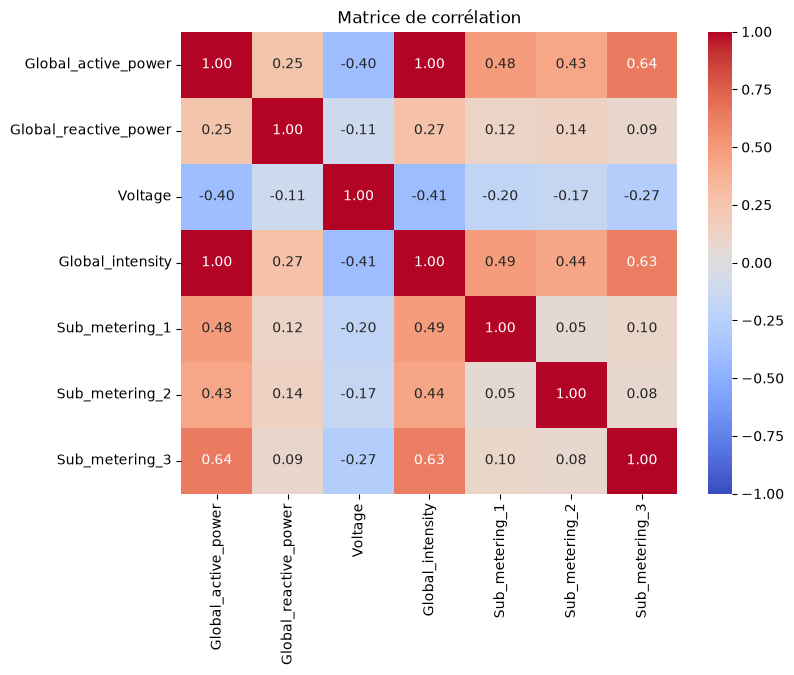

Global_active_power  Global_intensity    0.998889
dtype: float64


In [9]:
# TO DO
num_att = df.select_dtypes(include="number")
corr = num_att.corr()

# Afficher la matrice de corrélation
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matrice de corrélation")
plt.show()

# Afficher les paires d'attributs fortement corrélés
threshold = 0.75
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
strong_pairs = pairs[pairs.abs() > threshold].sort_values(ascending=False)
print(strong_pairs)

b- Afficher sur un graphe la relation entre les deux attributs ayant la plus forte corrélation. Commenter la figure obtenue.

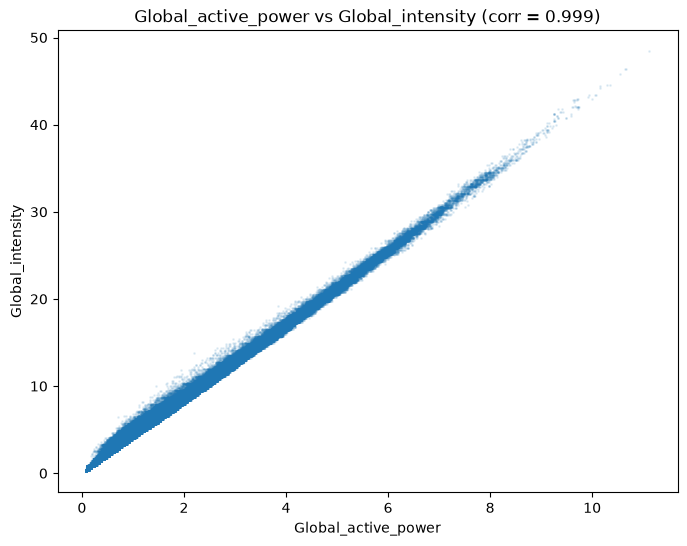

Moyenne de Voltage : 240.84
Coefficient de variation : 1.35 %


In [10]:
# TO DO
x, y = strong_pairs.index[0]

plt.figure(figsize=(8, 6))
plt.scatter(df[x], df[y], alpha=0.1, s=1)
plt.xlabel(x)
plt.ylabel(y)
plt.title(f"{x} vs {y} (corr = {corr.loc[x, y]:.3f})")
plt.show()

print(f"Moyenne de Voltage : {df['Voltage'].mean():.2f}")
print(f"Coefficient de variation : {df['Voltage'].std() / df['Voltage'].mean() * 100:.2f} %")

Réponse 1.5b :

En observant la figure, on remarque assez facilement une relation quasi linéaire entre les attributs numériques Global_active_power et Global_intensity. Ce résultat s'explique physiquement, puisque la puissance est le produit de la tension et de l'intensité (P = U x I). Étant donné que la tension, soit l'attribut numérique Voltage, varie légèrement autour de 240V, une augmentation de la puissance est généralement liée à une augmentation de l'intensité, conséquence de la loi physique qui relie ces deux attributs.

#### Question 1.6 (5 points)
Pour les parties suivantes du TP, on va séparer les données en un ensemble d'entraînement et un ensemble de test qu'on va nommer respectivement 'data_train' et 'data_test'. Utiliser les données jusqu'à fin 2009 pour l'apprentissage, et celles de 2010 pour le test.

Effectuer la séparartion des données.

In [11]:
# TO DO
data_train = df[df["dt"] < "2010-01-01"].copy()
data_test = df[df["dt"] >= "2010-01-01"].copy()

print(f"data_train : {len(data_train)} lignes, du {data_train['dt'].min()} au {data_train['dt'].max()}")
print(f"data_test : {len(data_test)} lignes, du {data_test['dt'].min()} au {data_test['dt'].max()}")

data_train : 1591886 lignes, du 2006-12-16 17:24:00 au 2009-12-31 23:59:00
data_test : 457394 lignes, du 2010-01-01 00:00:00 au 2010-11-26 21:02:00


Dans les parties 2 et 3, les opérations se feront uniquement sur les données d'entraînement.  Aucune transformation des données de test ne devra être effectuer. Les données de test doivent être utilisés uniquement pour l'évaluation de modèle.

# 2. Prédiction standard
De façon classique, un modèle de prédiction indique une relation entre des variables d'entrée et une variable à prédire. Dans cette partie, nous allons prédire  **Global_active_power** en utilisant les autres colonnes.

#### Question 2.1   (5 points)
Pour l'ensemble des données d'entraînement, créer un ensemble de données nommé **data** en remplaçant la colonne **dt** par de nouvelles colonnes **annee**, **mois**, **jour**, **heure** et **minutes**.
Indiquer pourquoi la colonne **secondes** peut être ignorée pour notre ensemble de données.

In [12]:
# TO DO
data = data_train.copy()

data["annee"] = data["dt"].dt.year
data["mois"] = data["dt"].dt.month
data["jour"] = data["dt"].dt.day
data["heure"] = data["dt"].dt.hour
data["minutes"] = data["dt"].dt.minute

data = data.drop(columns=["dt"])
data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,annee,mois,jour,heure,minutes
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006,12,16,17,24
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006,12,16,17,25
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006,12,16,17,26
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006,12,16,17,27
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006,12,16,17,28


Réponse 2.1:

Tel qu'indiqué dans la section « Informations sur les données », bien que Time soit au format hh:mm:ss, les mesures sont des moyennes par minute. Chaque observation correspond donc à une minute entière, et non à un instant précis à la second près. Le colonne secondes serait alors constante à 0 pour toutes les observations (variance nulle) et n'apporterait aucune information discriminante pour notre modèle de prédiction.

#### Question 2.2 (5 points)
On peut normaliser les données.

*   La `standardisation` normalise les données en soustrayant la moyenne et en divisant par l'écart-type
*   `Min-Max Scaling` normalise les données en les ramenant entre 0 et 1.

Réaliser la normalisation des données par `standardisation` pour toutes les attributs sauf ceux issues de 'dt' dans la question précédente. On peut utiliser la fonction `StandardScaler()` de `sklearn`.

In [13]:
# TO DO
from sklearn.preprocessing import StandardScaler

dt_cols = ["annee", "mois", "jour", "heure", "minutes"]
cols = [c for c in data.columns if c not in dt_cols]

scaler = StandardScaler()
# fit: Apprendre la moyenne et l'écart-type des données d'entraînement
# transform : Utiliser les statistiques apprises pour appliquer la standardisation
data[cols] = scaler.fit_transform(data[cols])

data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,annee,mois,jour,heure,minutes
0,2.857736,2.641943,-1.749768,2.994735,-0.184404,-0.059039,1.289969,2006,12,16,17,24
1,3.907056,2.802641,-2.114446,3.998119,-0.184404,-0.059039,1.170164,2006,12,16,17,25
2,3.919897,3.356158,-2.216918,3.998119,-0.184404,0.107234,1.289969,2006,12,16,17,26
3,3.932739,3.391869,-2.081294,3.998119,-0.184404,-0.059039,1.289969,2006,12,16,17,27
4,2.353255,3.623988,-1.496603,2.427606,-0.184404,-0.059039,1.289969,2006,12,16,17,28


### Question 2.4 - Entrainement de modèle de régression linéaire

La régression linéaire consiste à trouver une fonction affine qui minimise la somme des carrés des erreurs. La fonction affine est définie par la formule suivante :
$$ f(x) = \beta_0 + \beta_1^T x $$
Il consiste à trouver les paramètres $\beta_0$ et $\beta_1$ qui minimisent $\sum_{i=1}^n (f(x_i) - y_i)^2=||y-X\beta||^2$ où $X$ est la matrice des données fournies au modèle et $y$ le vecteur des `Global_active_power`.

La métrique RMSE (Root Mean Square Error) est une métrique utilisée pour mesurer la différence moyenne entre les valeurs prédites par un modèle et les valeurs observées.

#### Question 2.4.1 (15 points )
Entrainer un modèle de regresion linéaire avec **data**. Les valeurs prédites doivent être à l'échelle réelle de `Global_active_power` fournie. Calculer la RMSE correspondante aux données de l'ensemble de test.

In [14]:
# Séparer les variables explicatives de la variable à prédire
X_train = data.drop(columns=["Global_active_power"])
y_train = data["Global_active_power"]

# Créer et entraîner le modèle de régression linéaire
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

# Préparer l'ensemble de test de la même manière que l'ensemble d'entraînement
test = data_test.copy()

test["annee"] = test["dt"].dt.year
test["mois"] = test["dt"].dt.month
test["jour"] = test["dt"].dt.day
test["heure"] = test["dt"].dt.hour
test["minutes"] = test["dt"].dt.minute

test = test.drop(columns=["dt"])

# Standardiser les données de test avec le scaler appris sur l'entraînement
test_scaled = test.copy()
test_scaled[cols] = scaler.transform(test_scaled[cols])

# Variables explicatives de test
X_test = test_scaled.drop(columns=["Global_active_power"])

# Faire les prédictions
y_pred_scaled = model.predict(X_test)

# Remettre les prédictions à l'échelle réelle de Global_active_power
index_target = cols.index("Global_active_power")

y_pred = (
    y_pred_scaled * scaler.scale_[index_target]
    + scaler.mean_[index_target]
)

# Valeurs réelles
y_test = data_test["Global_active_power"]

# Calcul de la RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Réponse finale
print(f"La RMSE obtenue sur l'ensemble de test est de {rmse:.4f}.")

La RMSE obtenue sur l'ensemble de test est de 0.0394.


La prédiction est obtenue. On peut maintenant mesurer l'importance de chaque attribut dans la prédicition en se référant aux coefficients de la régression linéaire.
#### Question 2.4.2  (5 points)
Quels sont les trois attributs ayant le plus d'impact dans la prédiction ?

In [15]:
# TO DO
# Associer chaque attribut à son coefficient de régression
importance = pd.DataFrame({
    "Attribut": X_train.columns,
    "Coefficient": model.coef_
})

# Utiliser la valeur absolue du coefficient pour mesurer l'importance
importance["Impact"] = importance["Coefficient"].abs()

# Garder les trois attributs ayant le plus grand impact
top3 = importance.sort_values(by="Impact", ascending=False).head(3)

print("Les trois attributs ayant le plus d'impact dans la prédiction sont :")
print(top3[["Attribut", "Coefficient"]])

Les trois attributs ayant le plus d'impact dans la prédiction sont :
                Attribut  Coefficient
2       Global_intensity     0.999404
0  Global_reactive_power    -0.017992
5         Sub_metering_3     0.016897


# 3. Prédiction de série temporelle
Dans la partie précédente, la prédiction d'une valeur nécessite la connaissance des valeurs des autres attributs de l'observation concernée. On n'a pas toujours ces valeurs et pourtant on peut faire de prédiction ; les séries temporelles sont plus adaptées dans ces situations. La prédiction de séries temporelles consiste à estimer les valeurs futures d’une variable en se basant sur ses observations passées.

Dans la suite du TP, seuls les attributs **Global_active_power** et **dt** des données issues à la question 1.6 vont être utilisés. La cellule suivante permet de réduire les données.

## 3.1 Analyse préliminaire des données

#### Question 3.1.1 ( 3 points)
Pour l'ensenble d'entraînement, calculer et afficher sur un graphe la consommation moyenne de **Global_active_power** pour chaque mois de l'année.

dt
1     1.472052
2     1.275572
3     1.263567
4     1.053958
5     1.007666
6     0.888459
7     0.693449
8     0.567759
9     0.981280
10    1.128386
11    1.318757
12    1.489729
Name: Global_active_power, dtype: float64


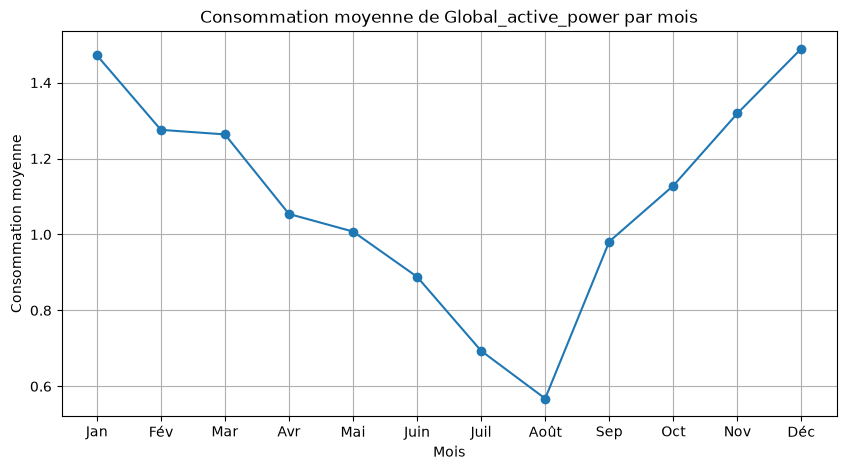

In [16]:
# TO DO
# Calculer la consommation moyenne pour chaque mois
conso_mensuelle = (
    data_train
    .groupby(data_train["dt"].dt.month)["Global_active_power"]
    .mean()
)

# Afficher les valeurs
print(conso_mensuelle)

# Afficher le graphique
plt.figure(figsize=(10, 5))

plt.plot(
    conso_mensuelle.index,
    conso_mensuelle.values,
    marker="o"
)

plt.title("Consommation moyenne de Global_active_power par mois")
plt.xlabel("Mois")
plt.ylabel("Consommation moyenne")
plt.xticks(
    range(1, 13),
    ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
     "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]
)

plt.grid()
plt.show()

La consommation est plus élevée en hiver, surtout en décembre et janvier. Elle diminue en été et atteint son minimum en août. On observe donc une saisonnalité.


Les données fournies sont en minutes. Pour la suite du TP, on va réduire la taille des données en faisant un rééchantillonnage des données en utilisant la somme par jour. La cellule suivante permet de faire cette réduction et de visualiser les données obtenues.

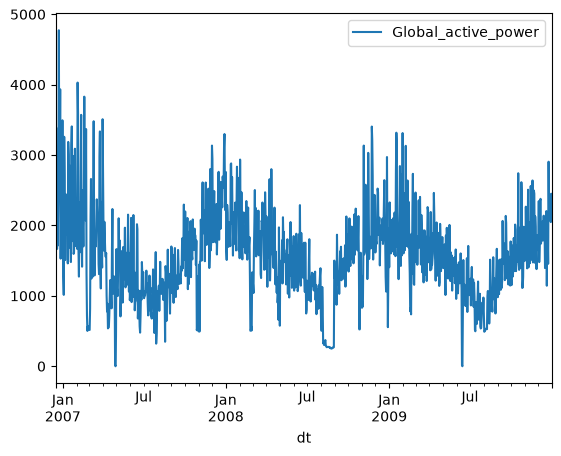

In [17]:
# Récupérer uniquement les données nécessaires pour la partie 3
dft = data_train[["dt", "Global_active_power"]].copy()

# Mettre la date comme index pour permettre le rééchantillonnage
dft = dft.set_index("dt")

# Somme de la consommation par jour
df_journalier = dft.resample("D").sum()

# Visualisation
df_journalier.plot()
plt.show()

#### Question 3.1.2 (3 points)
En utilisant la fonction **seasonal_decompose** de la librairie **statsmodels**, effectuer une décomposition de la série temporelle journalière (df_journalier) avec une période de 6 mois.

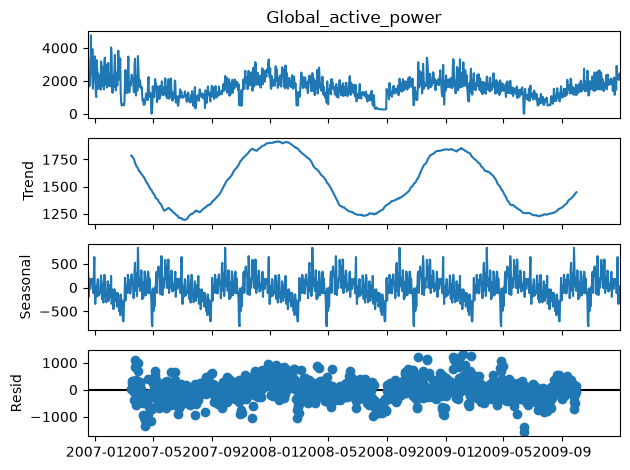

In [18]:
# TO DO

decomposition = seasonal_decompose(
    df_journalier["Global_active_power"],
    model="additive",
    period=182
)

decomposition.plot()
plt.show()

#### Question 3.1.3 (4 points)
Interpréter les résultats obtenus aux questions 3.1.1 et 3.1.2.
    Quelle périodicité observe-t-on ?
    Quels mois présentent une consommation plus élevée ?
    Cette information est-elle cohérente avec un usage domestique ?
    Justifier vos réponses.


#### Réponse : 
On observe une variation saisonnière de la consommation. La consommation est  a son pic en hiver, entre décembre et février, et plus faible en été. 
Ce qui est normale puisqu'en hiver l'utilisaion du chauffage et grande et implique donc une plus grande consommation d’électricité durant les mois froids.  

#### Question 3.1.4 (3 points)
Les **lag features** sont très utilisées dans la prédiction des séries temporelles. Elles permettent de saisir les tendances temporelles des données en générant de nouvelles variables à partir des valeurs passées. Ces variables permettent d'utiliser les valeurs passées pour prédire les valeurs futures. Par exemple, la prédiction de la consommation d'aujourd'hui pourrait dépendre de la consommation du même jour de l'année passée. Dans ce cas, la consommation d'il y a un an constituerait une lag feature.
Vous pouvez consulter le [lien](https://www.kaggle.com/code/ryanholbrook/time-series-as-features/tutorial) suivant pour un apperçu du lag embedding.


Quelle valeur est adéqate pour une variable lagged dans ce cas ? Justifier votre réponse.

#### Réponse : 

Une valeur de lag de 365 jours est adéquate, car la consommation présente une saisonnalité annuelle. 
La consommation d’un jour peut donc être liée à celle du même jour de l’année précédente.

### 3.2  Modèle de régression linéaire
Nous allons appliquer la régression linéaire sur nos données réduites. Pour cela, on doit transformer le problème de séries temporelles en un problème d'apprentissage supervisé. On va créer des "lagged features" pour accomplir cette tâche, puis diviser les données obtenues en des ensembles d'apprentissage et de test, respectivement les données jusqu'à fin 2009 pour l'apprentissage, et celles de 2010 pour le test.

#### Question 3.2 (10 points)
Entraîner un modèle de regresion linéaire dans ce cas. Pour cela, créer une variable 'lags' permettant de garder en mémoire à chaque jour la consommation d'un jour du passé. Calculer la RMSE correspondante aux données prédites.

In [19]:
# TO DO - Question 3.2
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Création de la série journalière complète
dft_full = df[["dt", "Global_active_power"]].copy().set_index("dt")
df_journalier_full = dft_full.resample("D").sum()

# Création de la variable lagged (consommation du même jour l'année précédente)
df_lag = df_journalier_full.copy()
df_lag["lags"] = df_lag["Global_active_power"].shift(365)

# Suppression des NaN introduits par le shift (premiers 365 jours)
df_lag = df_lag.dropna()

# Séparation train (jusqu'à fin 2009) / test (2010)
train_ts = df_lag[df_lag.index < "2010-01-01"]
test_ts  = df_lag[df_lag.index >= "2010-01-01"]

print(f"Train : {train_ts.shape[0]} jours ({train_ts.index.min().date()} → {train_ts.index.max().date()})")
print(f"Test  : {test_ts.shape[0]} jours ({test_ts.index.min().date()} → {test_ts.index.max().date()})")

# Variables pour la régression linéaire
X_train_ts = train_ts[["lags"]]
y_train_ts = train_ts["Global_active_power"]
X_test_ts  = test_ts[["lags"]]
y_test_ts  = test_ts["Global_active_power"]

# Entraînement du modèle de régression linéaire
model_lr_ts = linear_model.LinearRegression()
model_lr_ts.fit(X_train_ts, y_train_ts)

# Prédictions et RMSE
y_pred_lr_ts = model_lr_ts.predict(X_test_ts)
rmse_lr_ts = np.sqrt(mean_squared_error(y_test_ts, y_pred_lr_ts))
mae_lr_ts  = mean_absolute_error(y_test_ts, y_pred_lr_ts)

print(f"\nCoefficient (lag_365) : {model_lr_ts.coef_[0]:.4f}")
print(f"Intercept             : {model_lr_ts.intercept_:.4f}")
print(f"RMSE (régression linéaire) : {rmse_lr_ts:.4f}")
print(f"MAE  (régression linéaire) : {mae_lr_ts:.4f}")

Train : 747 jours (2007-12-16 → 2009-12-31)
Test  : 330 jours (2010-01-01 → 2010-11-26)

Coefficient (lag_365) : 0.3983
Intercept             : 927.8048
RMSE (régression linéaire) : 500.8606
MAE  (régression linéaire) : 378.9283


### 3.3 Entrainement d'un modèle au choix
#### Question 3.3 (10 points)
Pour les mêmes périodes de sous-ensembles de données, entrainer un modèle de votre choix et calculer la RMSE correspondante. Justifiez le choix de modèle. Il doit être différent de la regression linéaire.

Toute tranformation des données avant l'entrainement est autorisée ici mais doit être justifiée. La valeur de RMSE obtenu ici doit être meilleure à la valeur obtenue à la question précédente.

#### Réponse 

Pour cette question, nous avons choisi un Random Forest Regressor. Ce modèle présente plusieurs avantages par rapport à la régression linéaire. Il est capable de capturer des relations non linéaires entre les variables passées et la consommation future, ce qui s’avère particulièrement utile pour les séries temporelles énergétiques. Grâce au bagging et à l’agrégation de nombreux arbres, il reste relativement robuste au sur-apprentissage. Enfin, il gère naturellement des jeux de features hétérogènes sans nécessiter de normalisation préalable stricte.

Afin d’améliorer les performances, nous avons enrichi le jeu de variables. Outre le lag de 365 jours déjà utilisé, nous avons ajouté un lag d’un jour (fortement corrélé à la consommation du jour courant) et un lag de sept jours (pour capturer l’effet hebdomadaire). Deux variables calendaires, le mois et le jour de la semaine, ont également été introduites afin d’aider le modèle à modéliser explicitement la saisonnalité annuelle et les variations liées au week-end. Ces transformations sont justifiées par l’analyse exploratoire réalisée précédemment, qui a clairement mis en évidence à la fois une saisonnalité annuelle et une structure hebdomadaire dans les données

In [20]:
# TO DO - Question 3.3
from sklearn.ensemble import RandomForestRegressor

df_lag2 = df_journalier_full.copy()
df_lag2["lag_1"]   = df_lag2["Global_active_power"].shift(1)
df_lag2["lag_7"]   = df_lag2["Global_active_power"].shift(7)
df_lag2["lag_365"] = df_lag2["Global_active_power"].shift(365)
df_lag2["month"]   = df_lag2.index.month
df_lag2["dayofweek"] = df_lag2.index.dayofweek

df_lag2 = df_lag2.dropna()

train_ts2 = df_lag2[df_lag2.index < "2010-01-01"]
test_ts2  = df_lag2[df_lag2.index >= "2010-01-01"]

features = ["lag_1", "lag_7", "lag_365", "month", "dayofweek"]
X_train_ts2 = train_ts2[features]
y_train_ts2 = train_ts2["Global_active_power"]
X_test_ts2  = test_ts2[features]
y_test_ts2  = test_ts2["Global_active_power"]

# Entraînement du Random Forest
model_rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train_ts2, y_train_ts2)

# Prédictions et métriques
y_pred_rf = model_rf.predict(X_test_ts2)
rmse_rf = np.sqrt(mean_squared_error(y_test_ts2, y_pred_rf))
mae_rf  = mean_absolute_error(y_test_ts2, y_pred_rf)

print(f"RMSE (Random Forest) : {rmse_rf:.4f}")
print(f"MAE  (Random Forest) : {mae_rf:.4f}")
print(f"\nAmélioration relative de la RMSE par rapport à la régression linéaire :")
print(f"{(rmse_lr_ts - rmse_rf) / rmse_lr_ts * 100:.1f} %")

# Importance des features
importances = pd.Series(model_rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportance des variables :")
print(importances)

RMSE (Random Forest) : 392.7289
MAE  (Random Forest) : 277.7721

Amélioration relative de la RMSE par rapport à la régression linéaire :
21.6 %

Importance des variables :
lag_1        0.574694
lag_7        0.217651
lag_365      0.089034
month        0.067319
dayofweek    0.051302
dtype: float64


### 3.4 Évaluation des deux modèles

#### Question 3.4.1 (7 points)
Pour chacun des deux modèles précédents, afficher sur une figure les observations réelles de **Global_active_power** et celles prédites en fonction du temps pour l'année 2010.

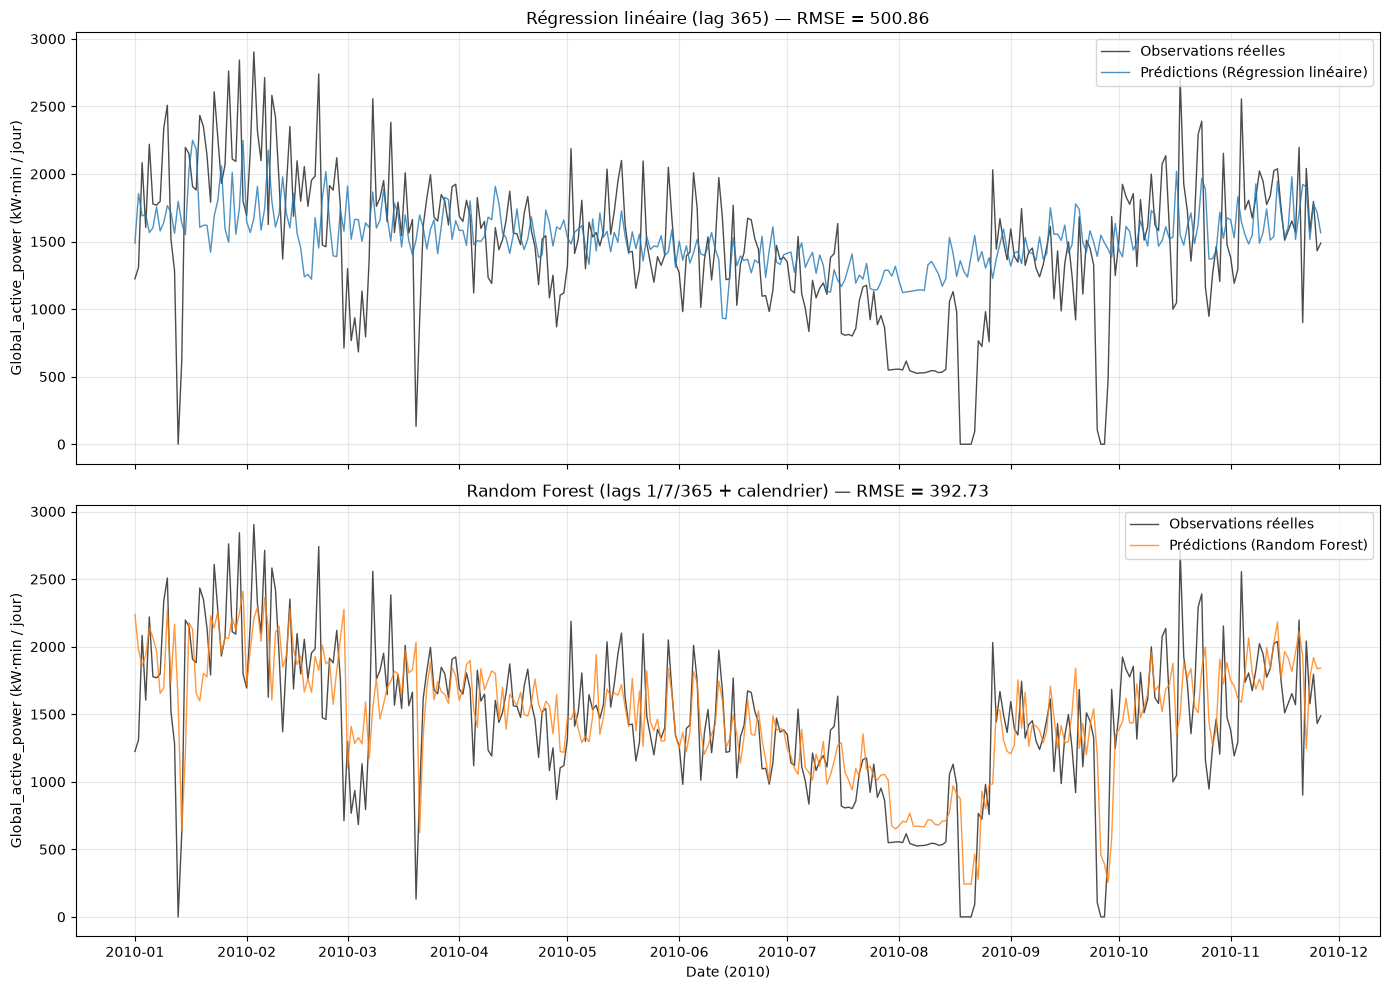

In [21]:
# TO DO - Question 3.4.1
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Régression linéaire ---
axes[0].plot(test_ts.index, y_test_ts.values, label="Observations réelles", color="black", alpha=0.7, linewidth=1)
axes[0].plot(test_ts.index, y_pred_lr_ts, label="Prédictions (Régression linéaire)", color="tab:blue", alpha=0.8, linewidth=1)
axes[0].set_title(f"Régression linéaire (lag 365) — RMSE = {rmse_lr_ts:.2f}")
axes[0].set_ylabel("Global_active_power (kW·min / jour)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# --- Random Forest ---
axes[1].plot(test_ts2.index, y_test_ts2.values, label="Observations réelles", color="black", alpha=0.7, linewidth=1)
axes[1].plot(test_ts2.index, y_pred_rf, label="Prédictions (Random Forest)", color="tab:orange", alpha=0.8, linewidth=1)
axes[1].set_title(f"Random Forest (lags 1/7/365 + calendrier) — RMSE = {rmse_rf:.2f}")
axes[1].set_xlabel("Date (2010)")
axes[1].set_ylabel("Global_active_power (kW·min / jour)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Question 3.4.2  (5 points)
En se basant sur les graphes obtenus à la question précédente, les RMSE obtenus pour les deux modèles et d'autres métriques de votre choix, faites une analyse comparative des résultats.

#### Réponse

L’évaluation des deux modèles sur l’année 2010 révèle des différences notables tant sur le plan quantitatif que qualitatif. La régression linéaire utilisant uniquement le lag de 365 jours obtient une RMSE d’environ 501 et une MAE d’environ 379. Le Random Forest, enrichi de lags à plusieurs échelles (1, 7 et 365 jours) ainsi que de variables calendaires, réduit ces erreurs à une RMSE d’environ 393 et une MAE d’environ 278, soit une amélioration relative de plus de 20 % sur la RMSE.

Sur le plan visuel, la régression linéaire capture correctement le niveau saisonnier global de la série : les pics hivernaux et le creux estival sont bien reproduits dans leur tendance générale. Cependant, le modèle lisse fortement les variations journalières et hebdomadaires. Il a notamment tendance à sous-estimer les pics de consommation les plus marqués. À l’inverse, le Random Forest suit beaucoup plus fidèlement les fluctuations locales. Grâce aux lags courts et aux informations de calendrier, il parvient à mieux reproduire les variations de jour en jour et les effets de fin de semaine, ce qui se traduit par une trajectoire prédite nettement plus proche des observations réelles, particulièrement durant la période hivernale.

Du point de vue de l’interprétabilité, la régression linéaire reste très simple : un seul coefficient permet de comprendre la relation entre la consommation de l’année précédente et celle de l’année en cours. Elle constitue donc une excellente baseline, stable et peu coûteuse en calcul. Le Random Forest offre de meilleures performances mais au prix d’une interprétabilité réduite. L’analyse des importances de variables montre néanmoins que les lags courts (notamment le lag d’un jour) jouent un rôle prépondérant, suivis du lag annuel et des variables de calendrier, ce qui confirme la pertinence des transformations choisies.

En conclusion, pour une tâche de prédiction purement basée sur l’historique de la série, l’enrichissement du jeu de features par des lags à différentes échelles temporelles combiné à un modèle non linéaire apporte un gain significatif de précision. La régression linéaire demeure néanmoins utile comme modèle de référence simple, interprétable et robuste.